!/usr/bin/env python
coding: utf-8

In [1]:
# # Task 1 – Exploratory Data Analysis
# **10 Academy KAIM-9 | Week 3: End-to-End Insurance Risk Analytics**
#
# **Objective:** Load the ACIS historical claims dataset, assess its quality,
# and uncover initial patterns in risk and profitability through descriptive
# statistics and well-designed visualisations.
#
# **Dataset:** 18 months of car-insurance policy, client, vehicle, and claim
# data (Feb 2014 – Aug 2015).

## 0. Setup – Imports and Configuration

In [2]:
# Standard library

# ── PATH FIX ──────────────────────────────────────────────────────────────
# Jupyter runs with the *notebook directory* as the working directory, so
# Python cannot find the top-level `src/` package without this fix.
# We walk up one level (from notebooks/ → project root) and add it to
# sys.path so that `from src.data_loader import ...` works regardless of
# how or where the notebook is launched.
import sys, pathlib
PROJECT_ROOT = pathlib.Path().resolve().parent   # notebooks/../  = project root
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print(f"Project root added to sys.path: {PROJECT_ROOT}")

import warnings
warnings.filterwarnings("ignore")

# Third-party
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Local source modules (from src/)
from src.data_loader import load_data, data_quality_report,engineer_base_features
from src.eda_utils import (
    plot_numerical_distributions,
    plot_categorical_distributions,
    plot_correlation_matrix,
    plot_scatter_premium_claims,
    plot_loss_ratio_by_group,
    plot_boxplots_outliers,
    plot_temporal_trends,
    plot_geographic_comparison,
    summarise_loss_ratio,
)

# Display settings
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.4f}".format)

Project root added to sys.path: C:\Users\hp\Documents\10x\insurance-market-analytics


## 1. Load Data

`load_data` reads the pipe-delimited CSV, enforces correct dtypes for all
numeric, categorical, and date columns, and appends `LossRatio` and `Margin`.

In [3]:
DATA_PATH = "../data/insurance_data.txt"

df = load_data(DATA_PATH)
df = engineer_base_features(df)

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.dtypes
df.head(15)

Dataset shape: 1,000,098 rows × 54 columns


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,MaritalStatus,Gender,Country,Province,PostalCode,MainCrestaZone,SubCrestaZone,ItemType,mmcode,VehicleType,RegistrationYear,make,Model,Cylinders,cubiccapacity,...,CustomValueEstimate,AlarmImmobiliser,TrackingDevice,CapitalOutstanding,NewVehicle,WrittenOff,Rebuilt,Converted,CrossBorder,NumberOfVehiclesInFleet,SumInsured,TermFrequency,CalculatedPremiumPerTerm,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims,LossRatio,Margin
0,145249,12827,2015-03-01,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,"44,069,150.0000",Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0000,"2,597.0000",...,"119,300.0000",Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,0.0100,Monthly,25.0000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.9298,0.0000,0.0000,21.9298
1,145249,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,"44,069,150.0000",Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0000,"2,597.0000",...,"119,300.0000",Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,0.0100,Monthly,25.0000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.9298,0.0000,0.0000,21.9298
2,145249,12827,2015-07-01,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,"44,069,150.0000",Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0000,"2,597.0000",...,"119,300.0000",Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,0.0100,Monthly,25.0000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.0000,0.0000,NaN,0.0000
3,145255,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,"44,069,150.0000",Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0000,"2,597.0000",...,"119,300.0000",Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,"119,300.0000",Monthly,584.6468,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.8481,0.0000,0.0000,512.8481
4,145255,12827,2015-07-01,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,"44,069,150.0000",Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0000,"2,597.0000",...,"119,300.0000",Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,"119,300.0000",Monthly,584.6468,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.0000,0.0000,NaN,0.0000
5,145247,12827,2015-01-01,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,"44,069,150.0000",Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0000,"2,597.0000",...,"119,300.0000",Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,"500,000.0000",Monthly,57.5412,No excess,Third Party,Third Party,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,3.2564,0.0000,0.0000,3.2564
6,145247,12827,2015-04-01,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,G

## 2. Data Summarization

### 2a. Descriptive statistics for numerical features

The `.describe()` call below surfaces the central tendency, spread, and
extreme values for all numeric columns.  Pay particular attention to
`TotalClaims` (right-skewed distributions are common in insurance) and
`LossRatio` (values > 1 indicate unprofitable policies).

In [4]:
print("=== DATA TYPES & OVERVIEW ===")
print(df.info())

print("\n=== DESCRIPTIVE STATISTICS ===")
display(df.describe())

=== DATA TYPES & OVERVIEW ===
<class 'pandas.DataFrame'>
RangeIndex: 1000098 entries, 0 to 1000097
Data columns (total 54 columns):
 #   Column                    Non-Null Count    Dtype         
---  ------                    --------------    -----         
 0   UnderwrittenCoverID       1000098 non-null  int64         
 1   PolicyID                  1000098 non-null  int64         
 2   TransactionMonth          1000098 non-null  datetime64[us]
 3   IsVATRegistered           1000098 non-null  bool          
 4   Citizenship               1000098 non-null  str           
 5   LegalType                 1000098 non-null  str           
 6   Title                     1000098 non-null  str           
 7   Language                  1000098 non-null  str           
 8   Bank                      854137 non-null   str           
 9   AccountType               959866 non-null   str           
 10  MaritalStatus             991839 non-null   str           
 11  Gender                    99056

,UnderwrittenCoverID,PolicyID,TransactionMonth,PostalCode,mmcode,RegistrationYear,Cylinders,cubiccapacity,kilowatts,NumberOfDoors,CustomValueEstimate,NumberOfVehiclesInFleet,SumInsured,CalculatedPremiumPerTerm,TotalPremium,TotalClaims,LossRatio,Margin
count,"1,000,098.0000","1,000,098.0000",1000098,"1,000,098.0000","999,546.0000","1,000,098.0000","999,546.0000","999,546.0000","999,546.0000","999,546.0000","220,456.0000",0.0000,"1,000,098.0000","1,000,098.0000","1,000,098.0000","1,000,098.0000","618,464.0000","1,000,098.0000"
mean,"104,817.5461","7,956.6825",2015-02-28 10:49:29.147424,"3,020.6009","54,877,704.0205","2,010.2254",4.0466,"2,466.7433",97.2079,4.0192,"225,531.1299",NaN,"604,172.7326",117.8757,61.9055,64.8612,0.3499,-2.9557
min,1.0000,14.0000,2013-10-01 00:00:00,1.0000,"4,041,200.0000","1,987.0000",0.0000,0.0000,0.0000,0.0000,"20,000.0000",NaN,0.0100,0.0000,-782.5768,"-12,002.4123",-18.7001,"-392,848.5669"
25%,"55,143.0000","4,500.0000",2015-01-01 00:00:00,827.0000,"60,056,925.0000","2,008.0000",4.0000,"2,237.0000",75.0000,4.0000,"135,000.0000",NaN,"5,000.0000",3.2248,0.0000,0.0000,0.0000,0.0000
50%,"94,083.0000","7,071.0000",2015-04-01 00:00:00,"2,000.0000","60,058,415.0000","2,011.0000",4.0000,"2,694.0000",111.0000,4.0000,"220,000.0000",NaN,"7,500.0000",8.4369,2.1783,0.0000,0.0000,2.1577
75%,"139,190.0000","11,077.0000",2015-06-01 00:00:00,"4,180.0000","60,058,418.0000","2,013.0000",4.0000,"2,694.0000",111.0000,4.0000,"280,000.0000",NaN,"250,000.0000",90.0000,21.9298,0.0000,0.0000,21.9298
max,"301,175.0000","23,246.0000",2015-08-01 00:00:00,"9,870.0000","65,065,350.0000","2,015.0000",10.0000,"12,880.0000",309.0000,6.0000,"26,550,000.0000",NaN,"12,636,200.0000","74,422.1679","65,282.6034","393,092.1053","2,553.6000","65,282.6034"
std,"63,293.7085","5,290.0385",NaN,"2,649.8544","13,603,805.3436",3.2614,0.2940,442.8006,19.3933,0.4683,"564,515.7498",NaN,"1,508,331.8380",399.7017,230.2845,"2,384.0747",9.2865,"2,367.1365"


## 3. Data Quality Assessment

`get_quality_report` returns a DataFrame sorted by `missing_pct` so the
most problematic columns appear first.  Columns with > 30 % missing values
will be considered for removal; columns with < 5 % missing values will be
imputed during modeling.

In [5]:
report = data_quality_report(df)
print(report.columns.tolist())  # see exact names
report.head()

['dtype', 'missing_count', 'missing_pct', 'unique']


,dtype,missing_count,missing_pct,unique
UnderwrittenCoverID,int64,0,0.0000,116532
PolicyID,int64,0,0.0000,7000
TransactionMonth,datetime64[us],0,0.0000,23
IsVATRegistered,bool,0,0.0000,2
Citizenship,str,0,0.0000,4


In [6]:
df["LossRatio"] = pd.to_numeric(df["LossRatio"], errors="coerce")

# Verify
print(df["LossRatio"].dtype)  # should now be float64

float64


## 4. Univariate Analysis

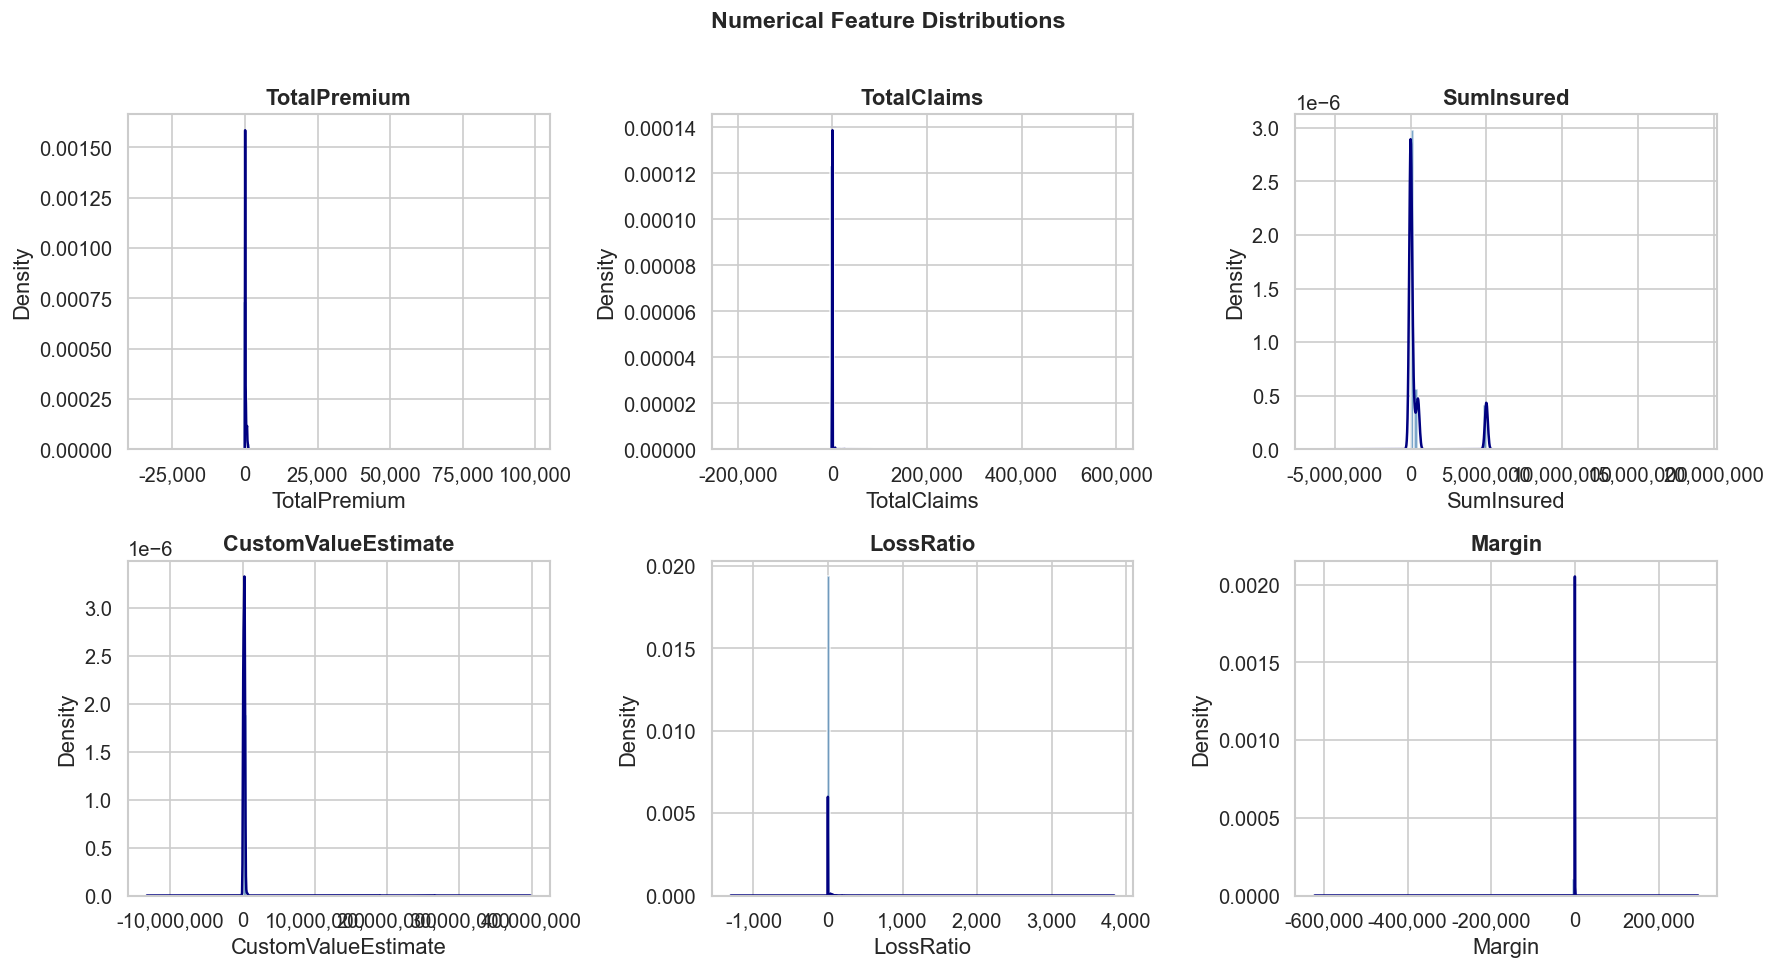

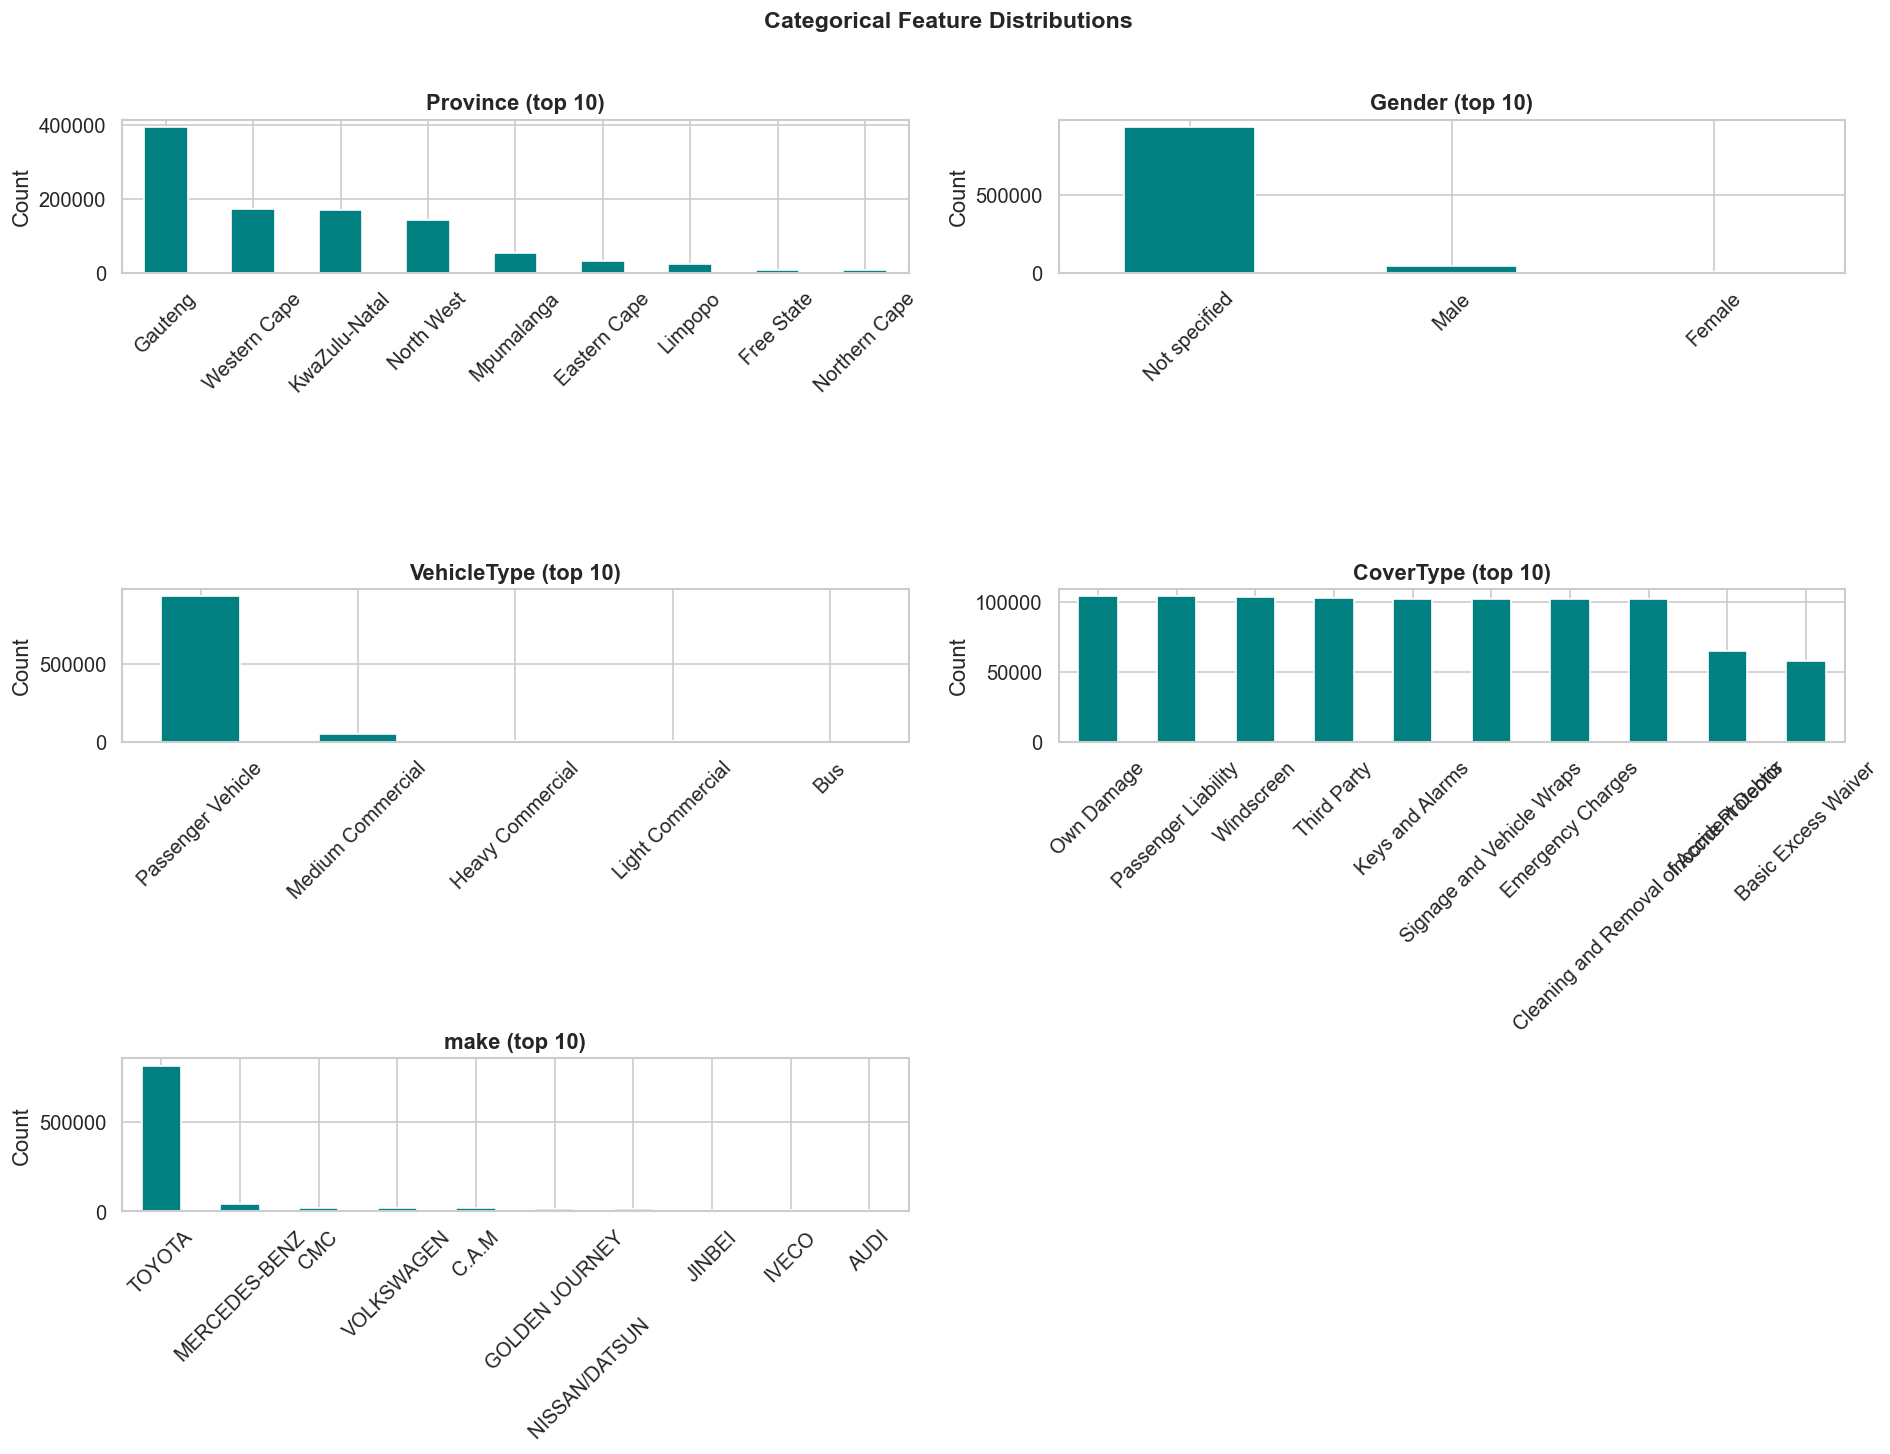

In [7]:
# ### 4a. Numerical distributions
#
# Histograms with KDE overlays reveal skewness in financial variables.
# `TotalPremium` and `TotalClaims` are expected to be right-skewed — a log
# transformation may be necessary before linear modeling.

fig_num = plot_numerical_distributions(
    df,
    cols=["TotalPremium", "TotalClaims", "SumInsured",
          "CustomValueEstimate", "LossRatio", "Margin"],
)
plt.show()

# ### 4b. Categorical distributions
#
# Bar charts for the most frequent categories across client, location, and
# vehicle attributes.  Imbalanced categories (e.g. one dominant province)
# should inform stratified sampling in later tasks.

fig_cat = plot_categorical_distributions(
    df,
    cols=["Province", "Gender", "VehicleType", "CoverType", "make"],
    top_n=10,
)
plt.show()

## 5. Bivariate / Multivariate Analysis

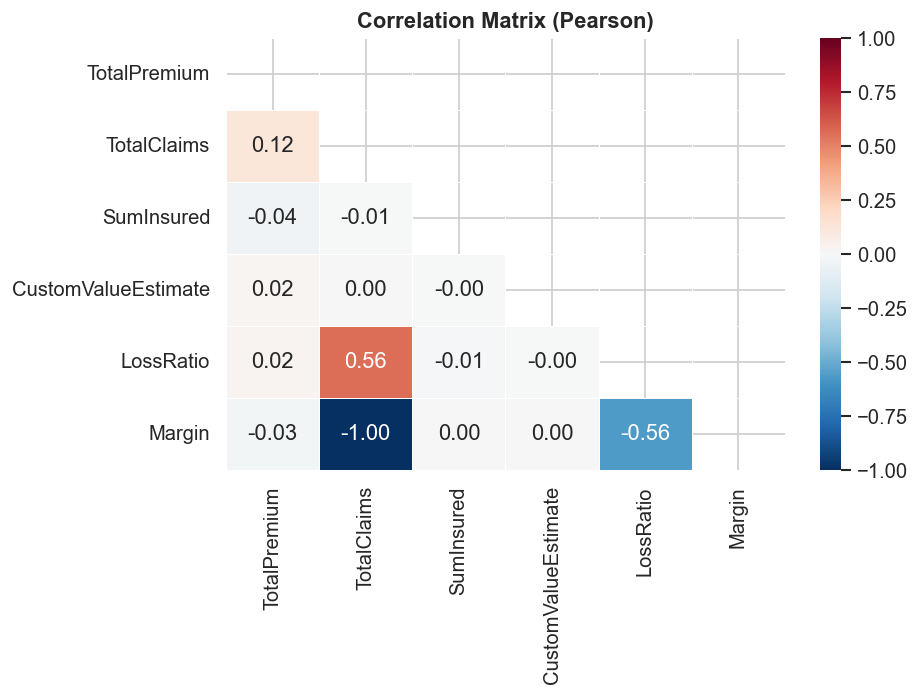

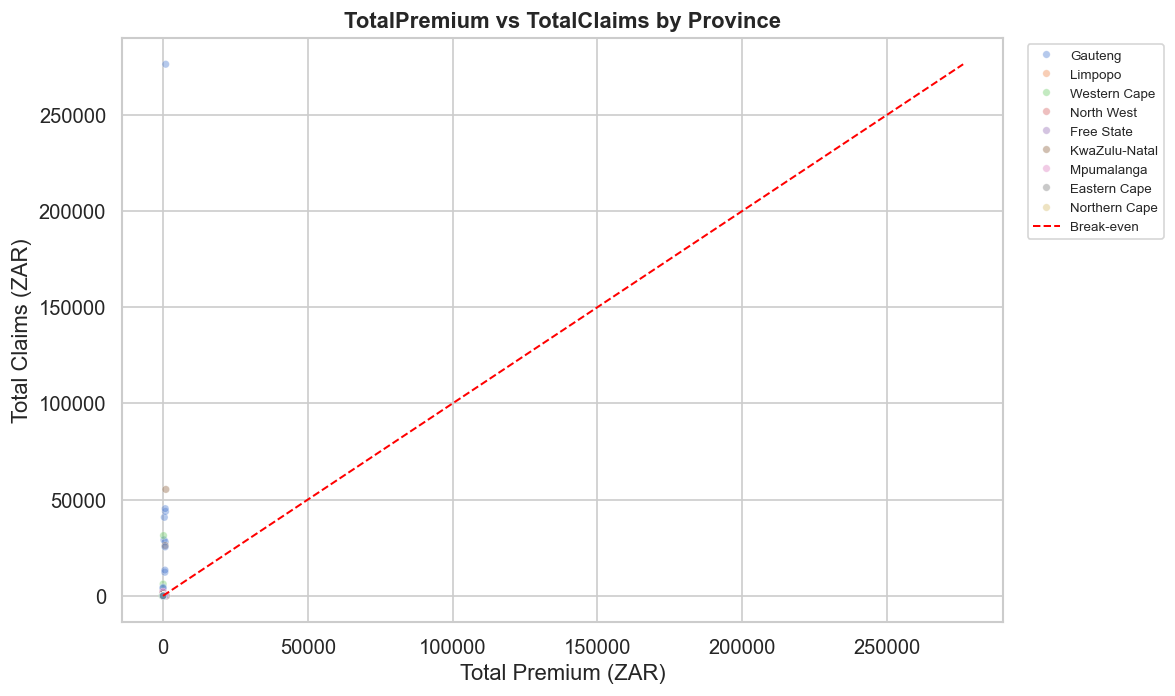

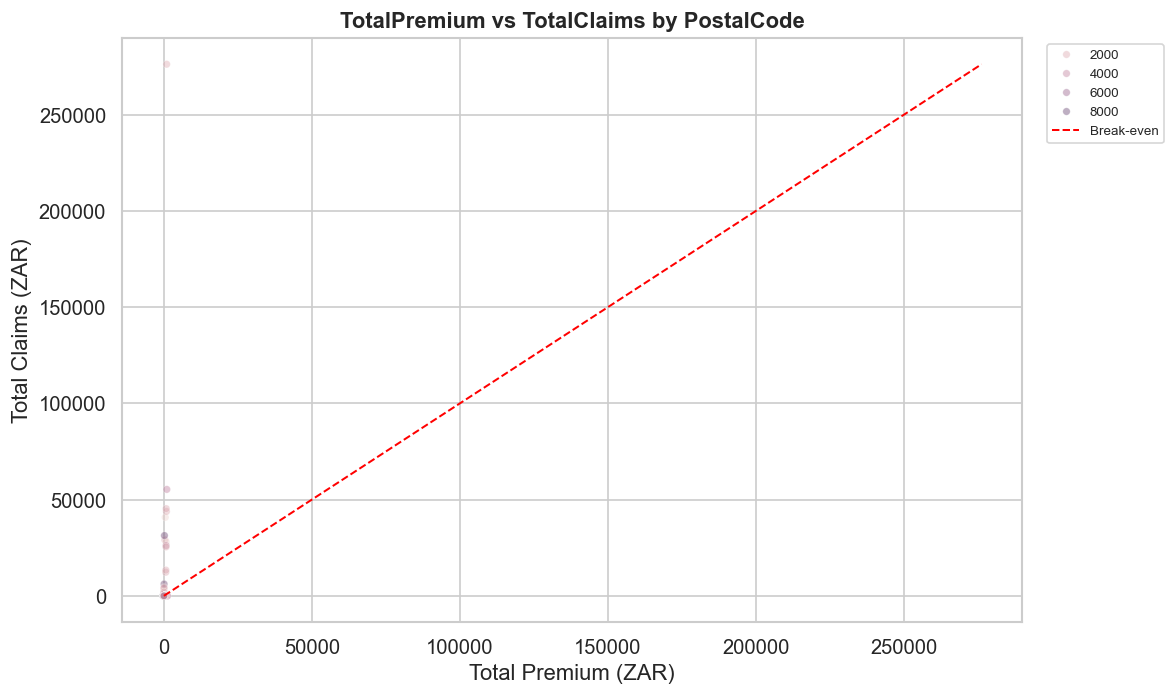

In [8]:
# ### 5a. Correlation matrix
#
# The Pearson correlation matrix highlights linear relationships between
# numeric features.  Strong correlations with `TotalClaims` are valuable
# inputs for the predictive model in Task 4.

fig_corr = plot_correlation_matrix(
    df,
    cols=["TotalPremium", "TotalClaims", "SumInsured",
          "CustomValueEstimate", "LossRatio", "Margin"],
)
plt.show()

# ### 5b. TotalPremium vs TotalClaims by Province
#
# Each point is one policy.  Points above the 45-degree break-even line
# (red dashes) represent policies where claims exceeded the premium collected
# — these are loss-making.  Clustering by Province reveals whether certain
# regions systematically generate higher-than-expected claims.

fig_scatter = plot_scatter_premium_claims(df, hue_col="Province", sample_n=8000)
plt.show()

# ### 5c. TotalPremium vs TotalClaims by ZipCode (PostalCode)
#
# Same chart but coloured by PostalCode to explore sub-provincial variation.

fig_scatter_zip = plot_scatter_premium_claims(df, hue_col="PostalCode", sample_n=8000)
plt.show()

## 6. Geographic Trends

Compare Loss Ratio across provinces.  Red bars exceed the portfolio
average (dashed line), indicating regions where ACIS is under-pricing risk.

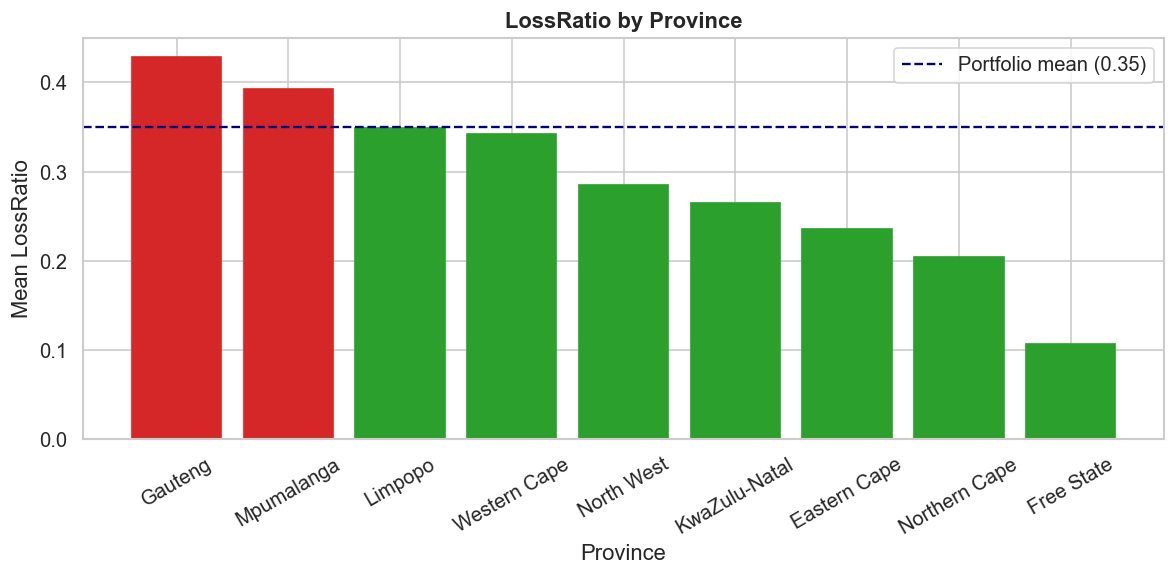

     Province  policy_count  mean_loss_ratio  median_loss_ratio  std_loss_ratio   total_premium    total_claims  portfolio_loss_ratio
      Gauteng        393865           0.4289             0.0000         10.3182 24,053,774.5827 29,394,148.4768                1.2220
KwaZulu-Natal        169781           0.2647             0.0000          5.7900 13,209,079.8122 14,301,382.4493                1.0827
 Western Cape        170796           0.3418             0.0000         12.7733  9,806,558.5289 10,389,773.7365                1.0595
   North West        143287           0.2853             0.0000          6.6231  7,490,508.1785  5,920,249.9951                0.7904
   Mpumalanga         52718           0.3927             0.0000          8.3237  2,836,291.9427  2,044,675.3579                0.7209
   Free State          8099           0.1062             0.0000          3.8037    521,363.2450    354,922.2719                0.6808
      Limpopo         24836           0.3487             0.000

In [9]:
fig_geo = plot_geographic_comparison(df, kpi_col="LossRatio")
plt.show()

# Tabular summary — useful for the final report.
geo_summary = summarise_loss_ratio(df, group_col="Province")
print(geo_summary.to_string(index=False))

## 7. Outlier Detection

Box plots use the IQR rule to flag extreme values.  Policies with
`TotalClaims` far above the upper whisker likely represent large accidents
or fraud and may need separate treatment (e.g. winsorisation or a separate
high-severity model).

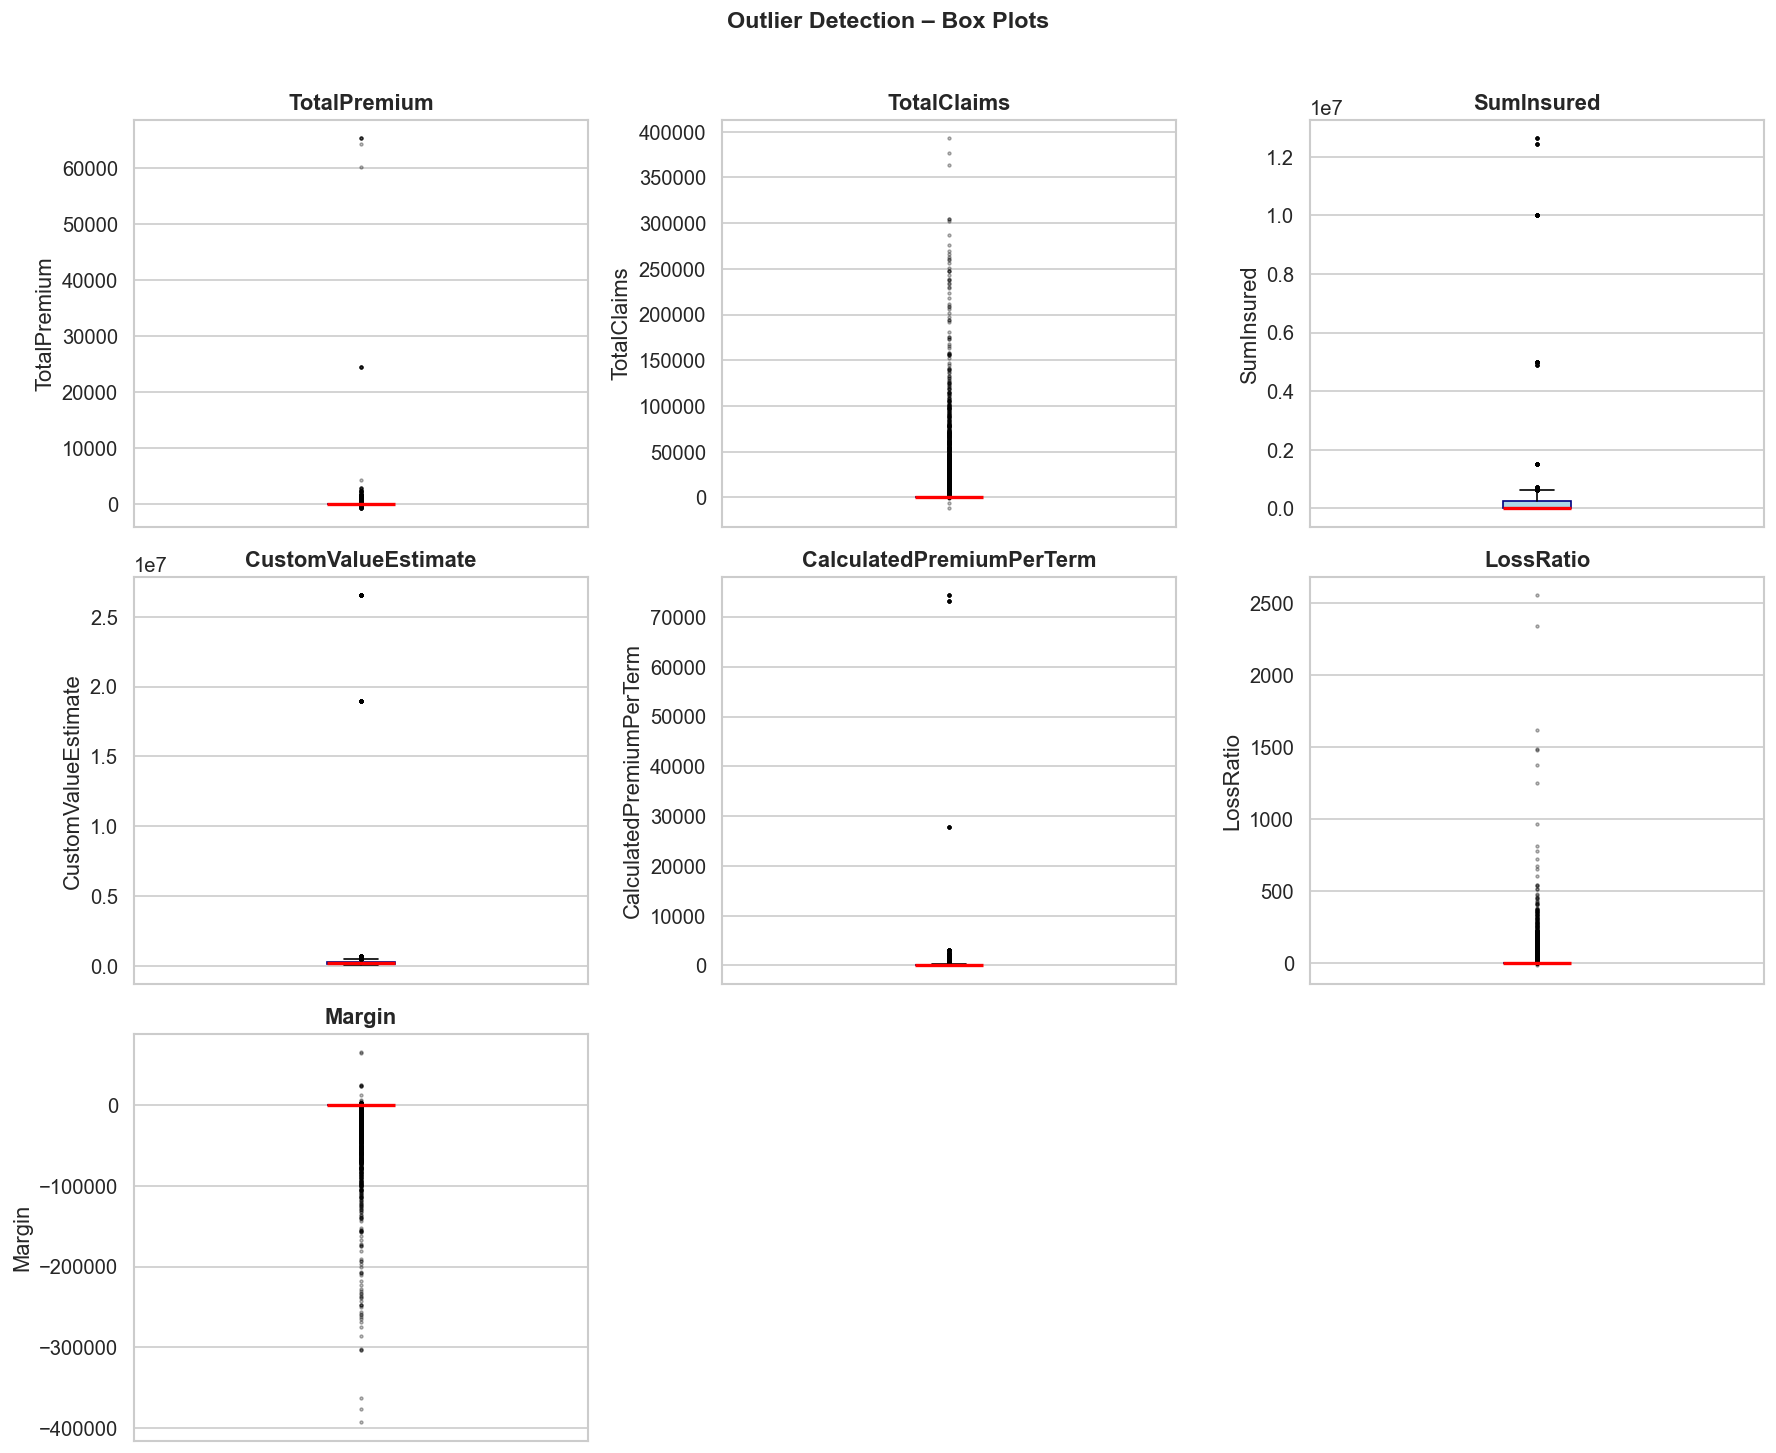

TotalPremium: 209,042 outliers (20.9% of policies)
TotalClaims: 2,793 outliers (0.3% of policies)
CustomValueEstimate: 1,785 outliers (0.2% of policies)


In [10]:
fig_box = plot_boxplots_outliers(df)
plt.show()

# Quantify outliers using the 1.5×IQR rule for key financial columns.
for col in ["TotalPremium", "TotalClaims", "CustomValueEstimate"]:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = ((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum()
    print(f"{col}: {n_out:,} outliers ({n_out / len(df):.1%} of policies)")

## 8. Guiding Questions

In [11]:
print(df["TransactionMonth"].dtype)
print(df["TransactionMonth"].head(5).tolist())

datetime64[us]
[Timestamp('2015-03-01 00:00:00'), Timestamp('2015-05-01 00:00:00'), Timestamp('2015-07-01 00:00:00'), Timestamp('2015-05-01 00:00:00'), Timestamp('2015-07-01 00:00:00')]


=== Loss Ratio by Province ===
     Province  policy_count  portfolio_loss_ratio
      Gauteng        393865                1.2220
KwaZulu-Natal        169781                1.0827
 Western Cape        170796                1.0595
   North West        143287                0.7904
   Mpumalanga         52718                0.7209
   Free State          8099                0.6808
      Limpopo         24836                0.6612
 Eastern Cape         30336                0.6338
Northern Cape          6380                0.2827

=== Loss Ratio by VehicleType ===
      VehicleType  policy_count  portfolio_loss_ratio
 Heavy Commercial          7401                1.6281
Medium Commercial         53985                1.0503
Passenger Vehicle        933598                1.0482
 Light Commercial          3897                0.2321
              Bus           665                0.1373

=== Loss Ratio by Gender ===
       Gender  policy_count  portfolio_loss_ratio
Not specified        940990   

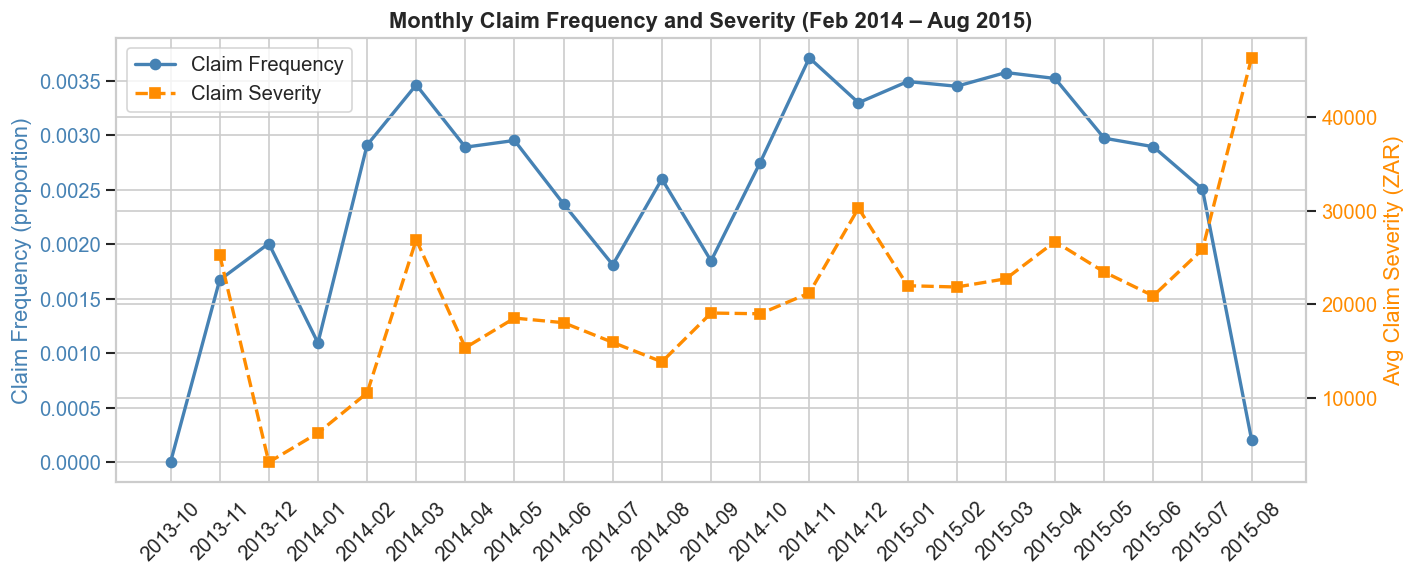

Top 10 makes by average claim amount:
                                     avg_claim  policy_count
make                                                        
SUZUKI                                419.6345           408
JMC                                   191.6848           120
HYUNDAI                               174.2152          2602
MARCOPOLO                             156.7948            51
AUDI                                  137.8431          7407
POLARSUN                              134.0448           934
B.A.W                                 132.9340          2160
FIAT                                  108.6256           984
BMW                                    90.5580          5317
IVECO                                  89.6670          8430

Bottom 10 makes by average claim amount:
                                     avg_claim  policy_count
make                                                        
GEELY                                   0.0000           108
HUMME

In [13]:
# ### Q1. Overall Loss Ratio — by Province, VehicleType, Gender
print("=== Loss Ratio by Province ===")
print(summarise_loss_ratio(df, "Province")[
    ["Province", "policy_count", "portfolio_loss_ratio"]
].to_string(index=False))

print("\n=== Loss Ratio by VehicleType ===")
print(summarise_loss_ratio(df, "VehicleType")[
    ["VehicleType", "policy_count", "portfolio_loss_ratio"]
].to_string(index=False))

print("\n=== Loss Ratio by Gender ===")
print(summarise_loss_ratio(df, "Gender")[
    ["Gender", "policy_count", "portfolio_loss_ratio"]
].to_string(index=False))

# ### Q2. Outliers in TotalClaims and CustomValueEstimate
# (Already computed in Section 7 above.)

# ### Q3. Temporal trends in claim frequency and severity
fig_temporal = plot_temporal_trends(df)
plt.show()

# ### Q4. Vehicle makes with highest and lowest claim amounts
make_claims = (
    df.groupby("make", observed=True)["TotalClaims"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "avg_claim", "count": "policy_count"})
    .query("policy_count >= 50")           # ignore very rare makes
    .sort_values("avg_claim", ascending=False)
)
print("Top 10 makes by average claim amount:")
print(make_claims.head(10).to_string())
print("\nBottom 10 makes by average claim amount:")
print(make_claims.tail(10).to_string())

## 9. Creative Insight Visualisations

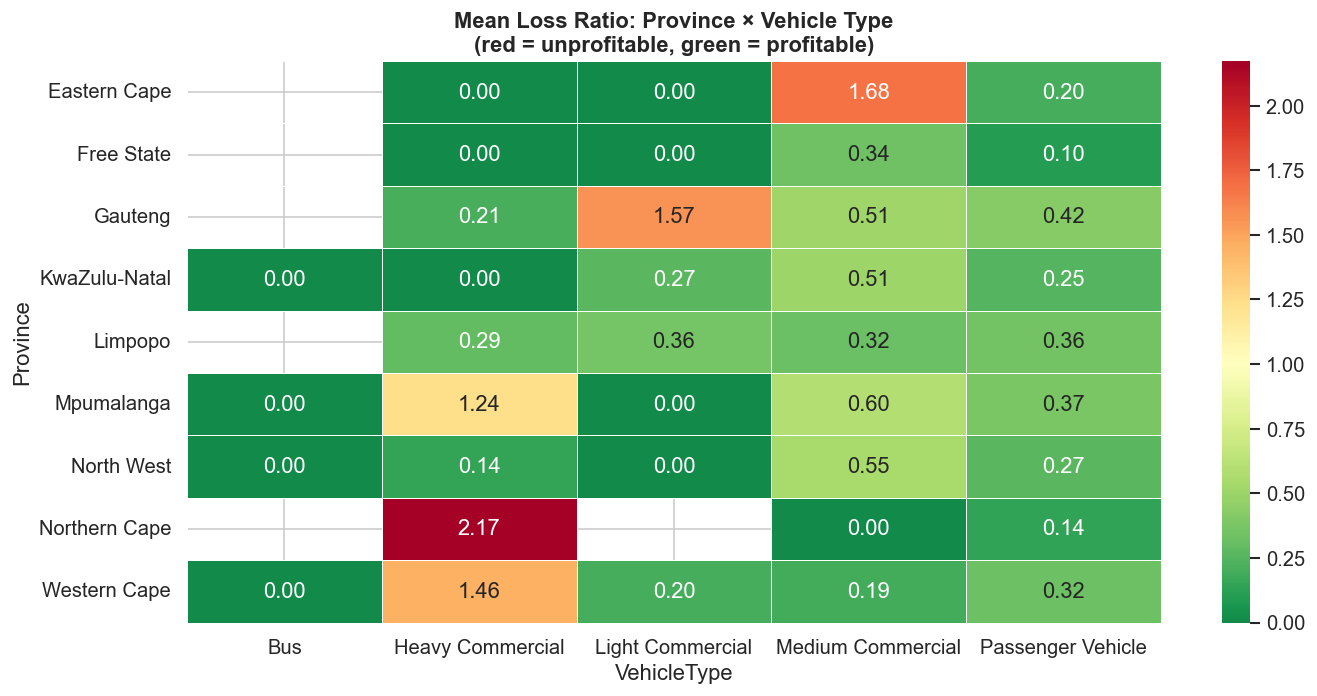

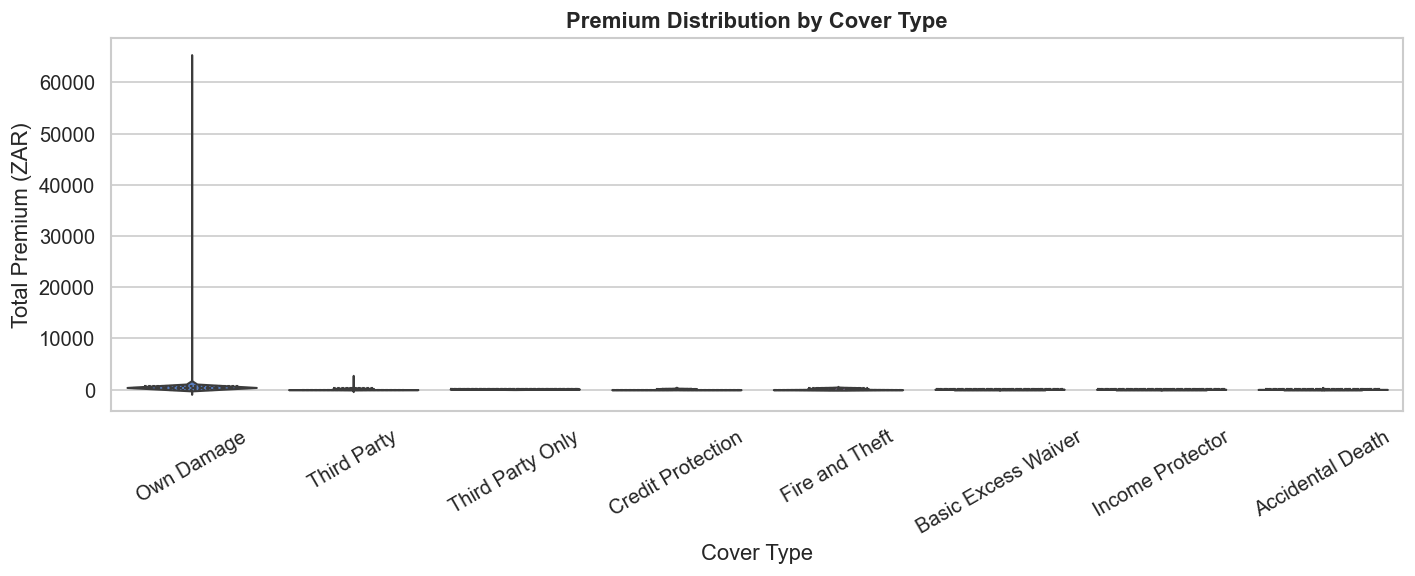

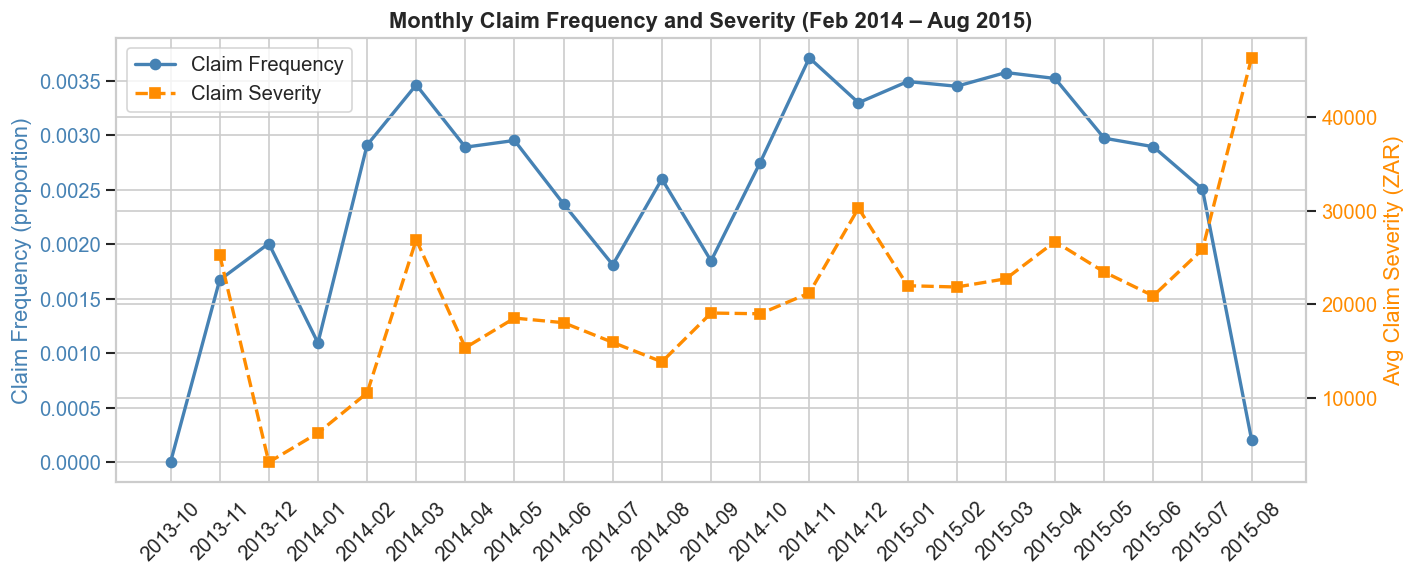


Task 1 EDA complete.


In [ ]:
# ### Plot A — Loss Ratio heatmap: Province × VehicleType
#
# A pivot table rendered as a heatmap reveals compound risk segments.
# For example, commercial vehicles in Gauteng may carry a fundamentally
# different risk profile than private passenger vehicles in the Western Cape.

pivot = (
    df.groupby(["Province", "VehicleType"], observed=True)["LossRatio"]
    .mean()
    .unstack("VehicleType")
)
fig_heatmap, ax = plt.subplots(figsize=(12, 6), dpi=120)
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn_r",
            linewidths=0.4, center=1.0, ax=ax)
ax.set_title("Mean Loss Ratio: Province × Vehicle Type\n"
             "(red = unprofitable, green = profitable)", fontweight="bold")
plt.tight_layout()
plt.show()

# ### Plot B — Premium distribution by Cover Type (violin)
#
# Violin plots combine the information of a box plot with a KDE, showing
# whether premium distributions within each cover type are unimodal or
# have multiple peaks (which might indicate hidden sub-segments).

fig_violin, ax = plt.subplots(figsize=(12, 5), dpi=120)
cover_order = (
    df.groupby("CoverType", observed=True)["TotalPremium"]
    .median()
    .sort_values(ascending=False)
    .index[:8]
)
sns.violinplot(
    data=df[df["CoverType"].isin(cover_order)],
    x="CoverType",
    y="TotalPremium",
    order=cover_order,
    palette="muted",
    inner="quartile",
    ax=ax,
)
ax.set_title("Premium Distribution by Cover Type", fontweight="bold")
ax.set_xlabel("Cover Type")
ax.set_ylabel("Total Premium (ZAR)")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

# ### Plot C — Monthly claim frequency vs severity (dual-axis trend)
#
# Already rendered in Section 8 (Q3), reproduced here as a standalone
# creative insight chart for the final report.

fig_trend = plot_temporal_trends(df)
plt.show()

